# LAB-D2-03 SOLUTION: Train a Neural Network with NumPy

**INSTRUCTOR ONLY - DO NOT DISTRIBUTE WITH PARTICIPANT MATERIALS**

**Objectives:** `OBJ-D2-01`, `OBJ-D2-03`, `OBJ-D2-04`, `OBJ-D2-05`, `OBJ-D2-06`  
**Reference environment:** local CPU; Python 3.11+; NumPy, matplotlib, scikit-learn; no network or GPU  
**Expected compute runtime:** baseline under 60 seconds; complete reference path under 10 seconds locally  
**Execution contract:** Clear outputs, restart the kernel, and run all cells from top to bottom.

This solution completes every training-loop stage in its participant location, then preserves the
NaN guard, representation failure, unstable-rate failure, one-change experiment, and optional second
experiment as separate evidence. Metric bands are sanity ranges under the supplied seeds.

In [1]:
import copy
import platform
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

np.set_printoptions(precision=5, suppress=True)
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.22})
print(f"Python {platform.python_version()} | NumPy {np.__version__} | matplotlib {matplotlib.__version__} | scikit-learn {sklearn.__version__}")
print("Runtime target: local/Colab CPU; no download or GPU required.")

Python 3.11.8 | NumPy 2.4.6 | matplotlib 3.11.1 | scikit-learn 1.9.0
Runtime target: local/Colab CPU; no download or GPU required.


## Recap: The Training-Loop State Machine

Each mini-batch moves through the same responsibilities:

`initialize -> forward/cache -> loss -> backward -> finite-state check -> update -> repeat -> evaluate`

An epoch contains multiple mini-batch updates. Validation examples may measure the current parameters, but they must not produce updates or preprocessing statistics.

## Local Dataset: Seeded, Stratified Moons

Generate 800 noisy examples, reserve 25% for validation with stratification, and standardize using training-set statistics only. Targets use shape `(B, 1)` because this lab's binary output also has shape `(B, 1)`. The same split specification is reused in `LAB-D2-04`.

In [2]:
DATA_SEED = 23
MODEL_SEED = 24
BATCH_SEED = 25
X_all, y_all = make_moons(n_samples=800, noise=0.27, random_state=DATA_SEED)
X_train_raw, X_val_raw, y_train_flat, y_val_flat = train_test_split(
    X_all, y_all, test_size=0.25, random_state=DATA_SEED, stratify=y_all
)
train_mean = X_train_raw.mean(axis=0, keepdims=True)
train_std = X_train_raw.std(axis=0, keepdims=True)
X_train = (X_train_raw - train_mean) / train_std
X_val = (X_val_raw - train_mean) / train_std
y_train = y_train_flat.reshape(-1, 1).astype(np.float64)
y_val = y_val_flat.reshape(-1, 1).astype(np.float64)
assert X_train.shape == (600, 2) and X_val.shape == (200, 2)
assert y_train.shape == (600, 1) and y_val.shape == (200, 1)
assert np.allclose(X_train.mean(axis=0), 0.0, atol=1e-12)
assert abs(y_train.mean() - y_val.mean()) < 0.01
print(f"Train: {X_train.shape}, positive rate {y_train.mean():.3f}")
print(f"Validation: {X_val.shape}, positive rate {y_val.mean():.3f}")

Train: (600, 2), positive rate 0.500
Validation: (200, 2), positive rate 0.500


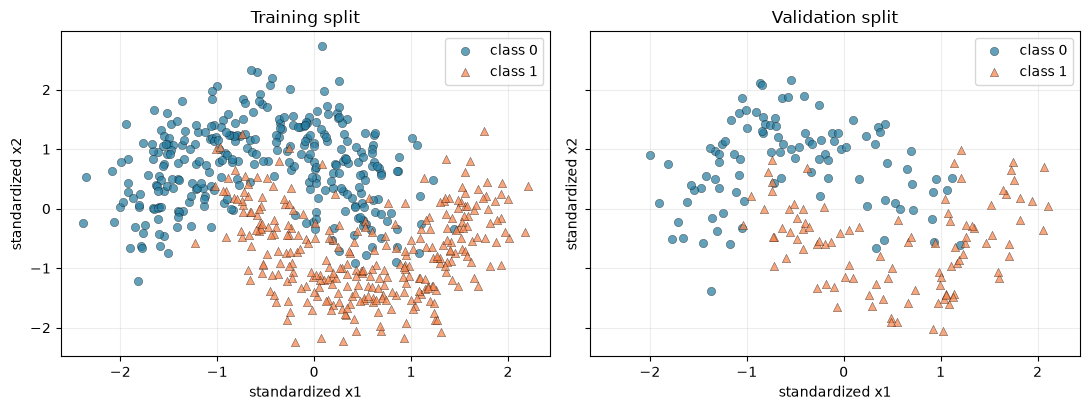

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True, sharey=True)
for ax, features, targets, title in [
    (axes[0], X_train, y_train_flat, 'Training split'),
    (axes[1], X_val, y_val_flat, 'Validation split'),
]:
    for label, marker, color in [(0, 'o', '#277da1'), (1, '^', '#f9844a')]:
        mask = targets == label
        ax.scatter(features[mask, 0], features[mask, 1], marker=marker, color=color, edgecolor='black', linewidth=0.3, alpha=0.72, label=f'class {label}')
    ax.set(title=title, xlabel='standardized x1', ylabel='standardized x2')
    ax.legend()
plt.tight_layout()
plt.show()

## Predict Before Building

For a `2 -> 8 -> 1` network with tanh hidden activation and sigmoid output, predict all parameter/cache shapes, the initial BCE band, the early loss direction, and the boundary family. Then predict how removing tanh differs from merely choosing a poor learning rate.

### Instructor Hint Ladder: Shape and Mechanism Map

(1) Write batch size only on activation/cache rows. (2) Derive each weight shape from adjacent layer
widths. (3) Compare the composition `affine -> identity -> affine` with `affine -> tanh -> affine`.
(4) Separate a representational hypothesis from an optimization hypothesis before giving ranges.

**Likely misconception:** Batch size changes parameter shapes. It changes example-carrying arrays,
not `W1`, `b1`, `W2`, or `b2`.

In [4]:
build_predictions = {
    "W1_b1_W2_b2_shapes": "W1 (2,8), b1 (8,), W2 (8,1), b2 (1,).",
    "Z1_A1_Z2_P_batch_shapes": "For batch B: Z1/A1 (B,8), Z2/P (B,1).",
    "initial_BCE_band": "Broadly 0.65-0.75, near log(2), because small seeded logits produce probabilities near 0.5.",
    "early_loss_direction": "Epoch-level loss should trend downward, though mini-batch updates need not be monotonic.",
    "baseline_boundary_family": "A curved/nonlinear boundary should emerge from tanh hidden features.",
    "no_activation_vs_bad_rate": "Identity hidden layers impose a linear representational limit; a poor rate is an optimization failure visible in unstable curves/gradients even when capacity exists.",
}
assert all(value.strip() for value in build_predictions.values()), (
    "Prediction checkpoint: complete every shape, range, and mechanism field before implementation."
)
print("Instructor build predictions recorded.")

Instructor build predictions recorded.


## Stage 1: Scaled Initialization

Complete `initialize_parameters`. Use the supplied generator and a scale proportional to $\sqrt{2/(d_{in}+d_{out})}$ for each weight matrix, multiplied by `gain`. Biases begin at zero. Return `W1`, `b1`, `W2`, and `b2`.

### Instructor Hint Ladder: Initialization

Ask for four shapes before any random draw. Then reveal the two scale expressions separately. Zero
biases are intentional here; they do not imply biases are permanently fixed or universally initialized
to zero in every architecture.

In [5]:
def initialize_parameters(input_dim, hidden_dim, output_dim, seed, gain=0.2):
    rng = np.random.default_rng(seed)
    W1_scale = gain * np.sqrt(2.0 / (input_dim + hidden_dim))
    W2_scale = gain * np.sqrt(2.0 / (hidden_dim + output_dim))
    return {
        "W1": rng.normal(0.0, W1_scale, size=(input_dim, hidden_dim)),
        "b1": np.zeros(hidden_dim, dtype=np.float64),
        "W2": rng.normal(0.0, W2_scale, size=(hidden_dim, output_dim)),
        "b2": np.zeros(output_dim, dtype=np.float64),
    }

baseline_parameters = initialize_parameters(2, 8, 1, MODEL_SEED)
assert baseline_parameters['W1'].shape == (2, 8)
assert baseline_parameters['b1'].shape == (8,)
assert baseline_parameters['W2'].shape == (8, 1)
assert baseline_parameters['b2'].shape == (1,)
assert all(np.all(np.isfinite(values)) for values in baseline_parameters.values())
print("Parameter shapes:", {name: values.shape for name, values in baseline_parameters.items()})

Parameter shapes: {'W1': (2, 8), 'b1': (8,), 'W2': (8, 1), 'b2': (1,)}


## Stage 2: Vectorized Forward Cache and Stable BCE

Implement stable sigmoid, forward propagation, and clipped BCE. `forward` supports `activation='tanh'` for the baseline and `activation='identity'` for a later controlled failure. Return `X`, `Z1`, `A1`, `Z2`, and `P`.

### Instructor Hint Ladder: Forward Contract

(1) Preserve `(B,1)` at the binary output. (2) Cache pre- and post-activation values. (3) Branch only
at the hidden activation. (4) Clip inside the loss, not inside the model output used for predictions.

In [6]:
def sigmoid(values):
    values = np.asarray(values, dtype=np.float64)
    output = np.empty_like(values)
    nonnegative = values >= 0
    output[nonnegative] = 1.0 / (1.0 + np.exp(-values[nonnegative]))
    exp_values = np.exp(values[~nonnegative])
    output[~nonnegative] = exp_values / (1.0 + exp_values)
    return output

def forward(X, parameters, activation='tanh'):
    Z1 = X @ parameters['W1'] + parameters['b1']
    if activation == 'tanh':
        A1 = np.tanh(Z1)
    elif activation == 'identity':
        A1 = Z1
    else:
        raise ValueError(f"Unsupported activation: {activation}")
    Z2 = A1 @ parameters['W2'] + parameters['b2']
    P = sigmoid(Z2)
    return {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "P": P}

def binary_cross_entropy(y_true, probabilities, epsilon=1e-12):
    y_true = np.asarray(y_true, dtype=np.float64)
    probabilities = np.asarray(probabilities, dtype=np.float64)
    clipped = np.clip(probabilities, epsilon, 1.0 - epsilon)
    return float(np.mean(-(y_true * np.log(clipped) + (1.0 - y_true) * np.log(1.0 - clipped))))

In [7]:
initial_cache = forward(X_train, baseline_parameters)
initial_loss = binary_cross_entropy(y_train, initial_cache['P'])
assert initial_cache['Z1'].shape == initial_cache['A1'].shape == (600, 8)
assert initial_cache['Z2'].shape == initial_cache['P'].shape == (600, 1)
assert np.all(np.isfinite(initial_cache['P']))
assert np.all((0.0 <= initial_cache['P']) & (initial_cache['P'] <= 1.0))
assert 0.65 <= initial_loss <= 0.75
print(f"Initial training BCE: {initial_loss:.6f}")
print("Initial cache shapes:", {name: value.shape for name, value in initial_cache.items()})

Initial training BCE: 0.686020
Initial cache shapes: {'X': (600, 2), 'Z1': (600, 8), 'A1': (600, 8), 'Z2': (600, 1), 'P': (600, 1)}


## Stage 3: Vectorized Backpropagation

Complete `backward`. Begin with sigmoid-plus-BCE output sensitivity, propagate through `W2`, and use either the tanh local derivative or identity derivative. Average over the current mini-batch and return gradient arrays keyed like the parameters.

In [8]:
def backward(cache, parameters, y_true, activation='tanh'):
    batch_size = y_true.shape[0]
    dZ2 = (cache['P'] - y_true) / batch_size
    dW2 = cache['A1'].T @ dZ2
    db2 = dZ2.sum(axis=0)
    dA1 = dZ2 @ parameters['W2'].T
    if activation == 'tanh':
        dZ1 = dA1 * (1.0 - cache['A1'] ** 2)
    elif activation == 'identity':
        dZ1 = dA1
    else:
        raise ValueError(f"Unsupported activation: {activation}")
    dW1 = cache['X'].T @ dZ1
    db1 = dZ1.sum(axis=0)
    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

initial_gradients = backward(initial_cache, baseline_parameters, y_train)
assert set(initial_gradients) == set(baseline_parameters)
for name in baseline_parameters:
    assert initial_gradients[name].shape == baseline_parameters[name].shape
    assert np.all(np.isfinite(initial_gradients[name]))
print("Gradient shapes:", {name: value.shape for name, value in initial_gradients.items()})

Gradient shapes: {'W1': (2, 8), 'b1': (8,), 'W2': (8, 1), 'b2': (1,)}


## Stage 4: Mini-Batches and Non-Mutating Updates

Implement a shuffled mini-batch iterator and parameter update. One epoch must visit every training example exactly once; the final batch may be smaller. Return new parameter arrays rather than mutating the input dictionary.

In [9]:
def mini_batches(X, y, batch_size, rng):
    indices = rng.permutation(len(X))
    for start in range(0, len(X), batch_size):
        batch_indices = indices[start:start + batch_size]
        yield X[batch_indices], y[batch_indices], batch_indices

def update_parameters(parameters, gradients, learning_rate):
    return {
        name: values - learning_rate * gradients[name]
        for name, values in parameters.items()
    }

batch_rng = np.random.default_rng(BATCH_SEED)
batch_index_groups = [indices for _, _, indices in mini_batches(X_train, y_train, 64, batch_rng)]
visited = np.concatenate(batch_index_groups)
assert len(batch_index_groups) == 10
assert np.array_equal(np.sort(visited), np.arange(len(X_train)))
assert len(np.unique(visited)) == len(X_train)
assert batch_index_groups[-1].shape == (24,)
print("Mini-batch sizes:", [len(indices) for indices in batch_index_groups])

Mini-batch sizes: [64, 64, 64, 64, 64, 64, 64, 64, 64, 24]


## Stage 5: Training Loop with Bounded Diagnostics

Complete `train_model`. Each epoch must shuffle mini-batches, run forward/backward/update, check finite parameters and gradients, and record train/validation loss, accuracy, and mean gradient norm. Refuse more than 2,000 epochs so an accidental unstable run cannot scroll indefinitely.

### Instructor Hint Ladder: Training Loop

Build the loop from invariants: one permutation per epoch, forward/backward on the current batch,
non-mutating update, finite-state check, then full train/validation evidence after the epoch. If a
participant writes the entire loop at once, ask them to test the mini-batch visitation invariant first.

In [10]:
def classification_accuracy(y_true, probabilities):
    return float(np.mean((probabilities >= 0.5).astype(int) == y_true.astype(int)))

def gradient_norm(gradients):
    return float(np.sqrt(sum(np.sum(values ** 2) for values in gradients.values())))

def require_finite_state(parameters, gradients, epoch, batch_index):
    parameter_ok = all(np.all(np.isfinite(values)) for values in parameters.values())
    gradient_ok = all(np.all(np.isfinite(values)) for values in gradients.values())
    if not parameter_ok or not gradient_ok:
        raise FloatingPointError(
            f"Non-finite state at epoch {epoch}, batch {batch_index}. Stop this run; inspect the rate, loss, and gradient norm."
        )

def train_model(X_train, y_train, X_val, y_val, *, hidden_dim, learning_rate, epochs, batch_size, activation, model_seed, batch_seed):
    if epochs > 2000:
        raise ValueError("epochs must not exceed the 2,000-epoch safety cap")
    parameters = initialize_parameters(X_train.shape[1], hidden_dim, y_train.shape[1], model_seed)
    rng = np.random.default_rng(batch_seed)
    history = {
        "train_loss": [], "val_loss": [], "train_accuracy": [],
        "val_accuracy": [], "gradient_norm": [],
    }
    for epoch in range(1, epochs + 1):
        batch_norms = []
        for batch_index, (X_batch, y_batch, _) in enumerate(
            mini_batches(X_train, y_train, batch_size, rng), start=1
        ):
            cache = forward(X_batch, parameters, activation)
            gradients = backward(cache, parameters, y_batch, activation)
            updated_parameters = update_parameters(parameters, gradients, learning_rate)
            require_finite_state(updated_parameters, gradients, epoch, batch_index)
            parameters = updated_parameters
            batch_norms.append(gradient_norm(gradients))
        train_cache = forward(X_train, parameters, activation)
        val_cache = forward(X_val, parameters, activation)
        history["train_loss"].append(binary_cross_entropy(y_train, train_cache['P']))
        history["val_loss"].append(binary_cross_entropy(y_val, val_cache['P']))
        history["train_accuracy"].append(classification_accuracy(y_train, train_cache['P']))
        history["val_accuracy"].append(classification_accuracy(y_val, val_cache['P']))
        history["gradient_norm"].append(float(np.mean(batch_norms)))
    return parameters, history

## Predict the Baseline Evidence

The baseline uses hidden width `8`, learning rate `0.6`, 600 epochs, batch size `64`, and tanh. Predict the final loss/accuracy bands, whether mini-batch loss must be monotonic, and what a healthy gradient-norm strip should rule out.

In [11]:
baseline_predictions = {
    "final_loss_band": "Training and validation BCE should generally finish below 0.35; roughly 0.15-0.30 is plausible for this seed.",
    "train_accuracy_band": "Approximately 0.85-0.95.",
    "validation_accuracy_band": "Approximately 0.85-0.95 without a large train/validation gap.",
    "mini_batch_monotonicity": "No. Individual batches and epochs can fluctuate even while the overall loss trend falls.",
    "gradient_norm_evidence": "Finite, bounded norms rule out NaN/Inf corruption and obvious explosion; they do not alone prove a useful boundary or generalization.",
}
assert all(value.strip() for value in baseline_predictions.values())
print("Instructor baseline predictions recorded.")

Instructor baseline predictions recorded.


In [12]:
baseline_config = {
    "hidden_dim": 8, "learning_rate": 0.6, "epochs": 600, "batch_size": 64,
    "activation": 'tanh', "model_seed": MODEL_SEED, "batch_seed": BATCH_SEED,
}
started = time.perf_counter()
trained_parameters, baseline_history = train_model(X_train, y_train, X_val, y_val, **baseline_config)
baseline_seconds = time.perf_counter() - started
baseline_train_cache = forward(X_train, trained_parameters)
baseline_val_cache = forward(X_val, trained_parameters)
baseline_train_loss = binary_cross_entropy(y_train, baseline_train_cache['P'])
baseline_val_loss = binary_cross_entropy(y_val, baseline_val_cache['P'])
baseline_train_accuracy = classification_accuracy(y_train, baseline_train_cache['P'])
baseline_val_accuracy = classification_accuracy(y_val, baseline_val_cache['P'])
print(f"Baseline runtime: {baseline_seconds:.3f}s")
print(f"Train loss/accuracy: {baseline_train_loss:.4f} / {baseline_train_accuracy:.3f}")
print(f"Validation loss/accuracy: {baseline_val_loss:.4f} / {baseline_val_accuracy:.3f}")
assert baseline_seconds < 60.0
assert baseline_train_loss < 0.35
assert 0.85 <= baseline_train_accuracy <= 0.95
assert 0.85 <= baseline_val_accuracy <= 0.95

Baseline runtime: 0.315s
Train loss/accuracy: 0.1857 / 0.915
Validation loss/accuracy: 0.1820 / 0.905


### Instructor Reveal: Calibrated Baseline

The clean local run should reproduce initial BCE near `0.6860`, final train/validation loss near
`0.186/0.182`, and train/validation accuracy near `0.915/0.905`. Treat `loss < 0.35` and accuracy
`0.85-0.95` as the portable sanity checks. The baseline is CPU-sized; accelerators add transfer
overhead and are unnecessary.

## Inspect: Baseline Evidence Dashboard

The dashboard separates optimization progress (loss and gradient norm), task performance (accuracy), and representation evidence (decision region). Shared epoch axes make train/validation comparison fair. A nonlinear boundary is visible evidence, not proof that every error is explained.

In [13]:
def make_mesh(X, padding=0.6, resolution=180):
    x1 = np.linspace(X[:, 0].min() - padding, X[:, 0].max() + padding, resolution)
    x2 = np.linspace(X[:, 1].min() - padding, X[:, 1].max() + padding, resolution)
    xx1, xx2 = np.meshgrid(x1, x2)
    return xx1, xx2, np.column_stack([xx1.ravel(), xx2.ravel()])

def plot_boundary(ax, parameters, activation, title):
    xx1, xx2, mesh = make_mesh(np.vstack([X_train, X_val]))
    mesh_probability = forward(mesh, parameters, activation)['P'].reshape(xx1.shape)
    ax.contourf(xx1, xx2, mesh_probability, levels=np.linspace(0, 1, 11), cmap='RdYlBu_r', alpha=0.45)
    ax.contour(xx1, xx2, mesh_probability, levels=[0.5], colors='black', linewidths=2)
    for label, marker, color in [(0, 'o', '#277da1'), (1, '^', '#f9844a')]:
        mask = y_val_flat == label
        ax.scatter(X_val[mask, 0], X_val[mask, 1], marker=marker, color=color, edgecolor='black', linewidth=0.3, s=30, label=f'class {label}')
    ax.set(title=title, xlabel='standardized x1', ylabel='standardized x2')
    ax.legend()

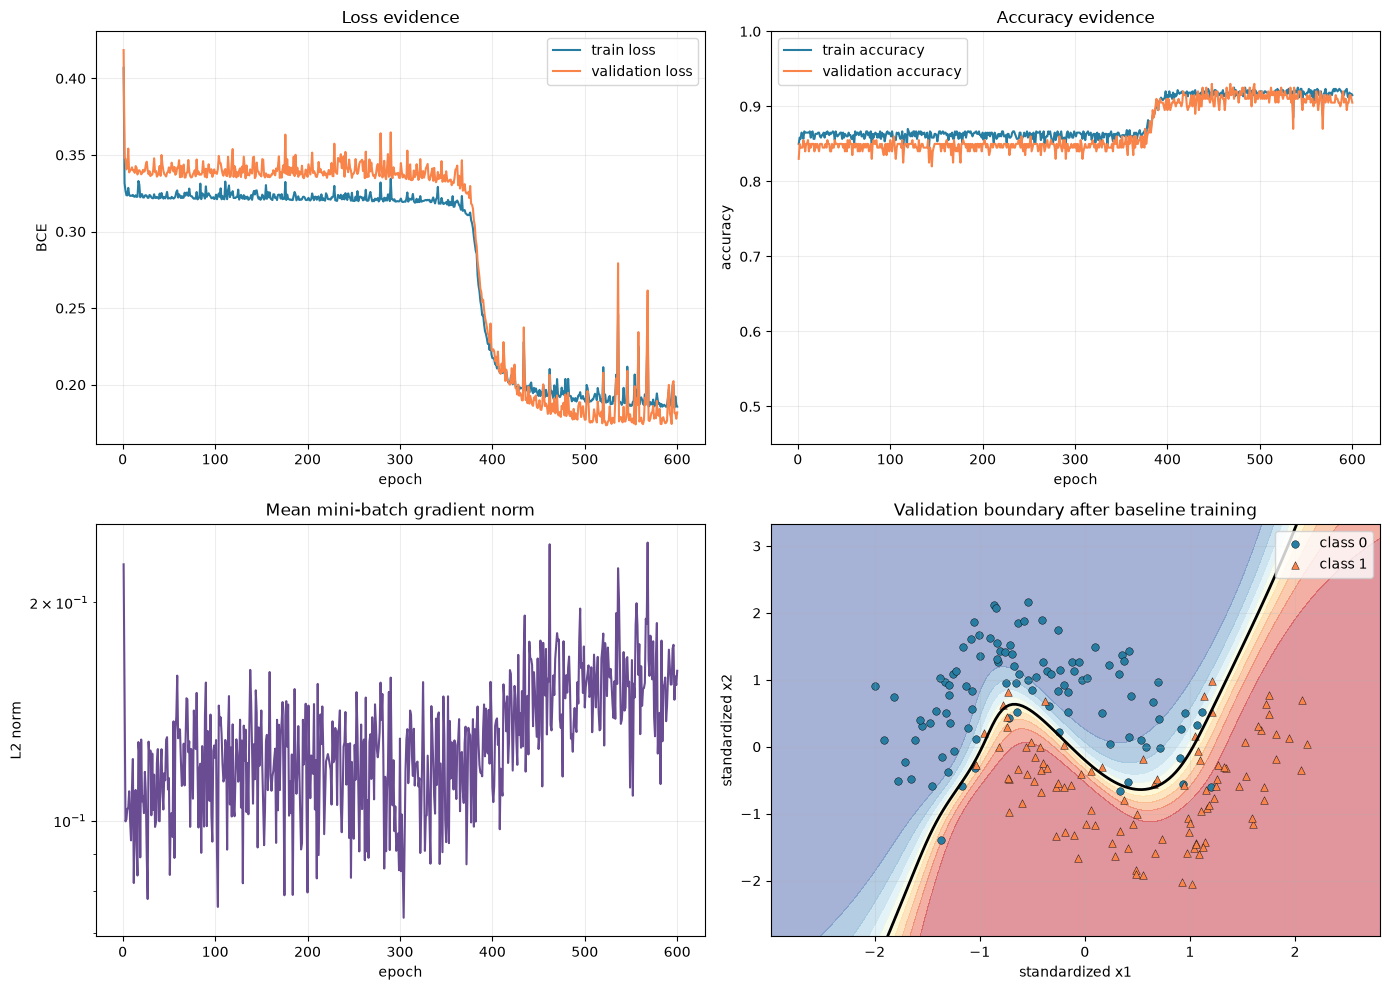

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
epochs_axis = np.arange(1, len(baseline_history['train_loss']) + 1)
axes[0, 0].plot(epochs_axis, baseline_history['train_loss'], label='train loss', color='#277da1')
axes[0, 0].plot(epochs_axis, baseline_history['val_loss'], label='validation loss', color='#f9844a')
axes[0, 0].set(title='Loss evidence', xlabel='epoch', ylabel='BCE')
axes[0, 0].legend()
axes[0, 1].plot(epochs_axis, baseline_history['train_accuracy'], label='train accuracy', color='#277da1')
axes[0, 1].plot(epochs_axis, baseline_history['val_accuracy'], label='validation accuracy', color='#f9844a')
axes[0, 1].set(title='Accuracy evidence', xlabel='epoch', ylabel='accuracy', ylim=(0.45, 1.0))
axes[0, 1].legend()
axes[1, 0].plot(epochs_axis, baseline_history['gradient_norm'], color='#6a4c93')
axes[1, 0].set(title='Mean mini-batch gradient norm', xlabel='epoch', ylabel='L2 norm', yscale='log')
plot_boundary(axes[1, 1], trained_parameters, 'tanh', 'Validation boundary after baseline training')
plt.tight_layout()
plt.show()

## Break It Safely: Prove the NaN Guard Stops

Predict the bounded message category before injecting one `nan` into a copied parameter dictionary. The canonical baseline remains untouched. Catching this deliberate failure demonstrates that a training run will stop at the first reported epoch/batch instead of continuing silently.

### Instructor Hint Ladder: Bounded Failure

Ask participants to predict the error category and location fields before injection. The copied
dictionary is the safety boundary: verify canonical parameters remain finite after the caught error.
Never use an uncaught deliberate exception in a Run All path.

In [15]:
nan_guard_prediction = "A FloatingPointError should name a non-finite state and report epoch 7, batch 3; the canonical trained parameters should remain finite."
assert nan_guard_prediction.strip()
corrupted_parameters = {name: values.copy() for name, values in trained_parameters.items()}
corrupted_parameters['W1'][0, 0] = np.nan
nan_guard_observed = False
try:
    require_finite_state(corrupted_parameters, initial_gradients, epoch=7, batch_index=3)
except FloatingPointError as error:
    nan_guard_observed = True
    print("Expected bounded diagnostic:", error)
assert nan_guard_observed
assert all(np.all(np.isfinite(values)) for values in trained_parameters.values())

Expected bounded diagnostic: Non-finite state at epoch 7, batch 3. Stop this run; inspect the rate, loss, and gradient norm.


## Diagnose Two Different Failures

Commit before running: predict the boundary family and accuracy of an identity-hidden network, then predict the curve/gradient symptoms of learning rate `30.0`. Name one check that distinguishes representational limitation from unstable optimization. Both variants start from the same seed and use separate parameter dictionaries.

### Instructor Hint Ladder: Failure Taxonomy

(1) Inspect whether loss is stable enough to evaluate the representation. (2) Inspect the boundary
family. (3) Compare gradient/loss volatility. A stable linear plateau and an unstable nonlinear model
require different repairs even if both have poor accuracy.

In [16]:
failure_predictions = {
    "identity_boundary_and_accuracy": "Composed affine layers remain affine, so the boundary stays linear and validation accuracy should stall near the linear-limit region, around 0.80-0.87.",
    "high_rate_curve_and_gradients": "Learning rate 30 should produce sharp loss oscillations or a bounded non-finite stop, with erratic/large gradient evidence rather than a stable descent trend.",
    "discriminating_check": "Inspect boundary family together with loss/gradient traces: a stable linear boundary indicates representation limits; unstable losses/norms indicate optimization failure.",
}
assert all(value.strip() for value in failure_predictions.values())
print("Instructor failure predictions recorded.")

Instructor failure predictions recorded.


In [17]:
identity_config = {**baseline_config, "activation": 'identity', "epochs": 300}
identity_parameters, identity_history = train_model(X_train, y_train, X_val, y_val, **identity_config)
identity_val_accuracy = classification_accuracy(y_val, forward(X_val, identity_parameters, 'identity')['P'])
high_rate_config = {**baseline_config, "learning_rate": 30.0, "epochs": 120}
high_rate_error = None
try:
    high_rate_parameters, high_rate_history = train_model(X_train, y_train, X_val, y_val, **high_rate_config)
except FloatingPointError as error:
    high_rate_parameters, high_rate_history, high_rate_error = None, None, str(error)
    print("High-rate run stopped by bounded diagnostic:", high_rate_error)
print(f"Identity-hidden validation accuracy: {identity_val_accuracy:.3f}")
if high_rate_history is not None:
    print(f"High-rate validation-loss range: {min(high_rate_history['val_loss']):.3f} to {max(high_rate_history['val_loss']):.3f}")

Identity-hidden validation accuracy: 0.850
High-rate validation-loss range: 0.432 to 8.216


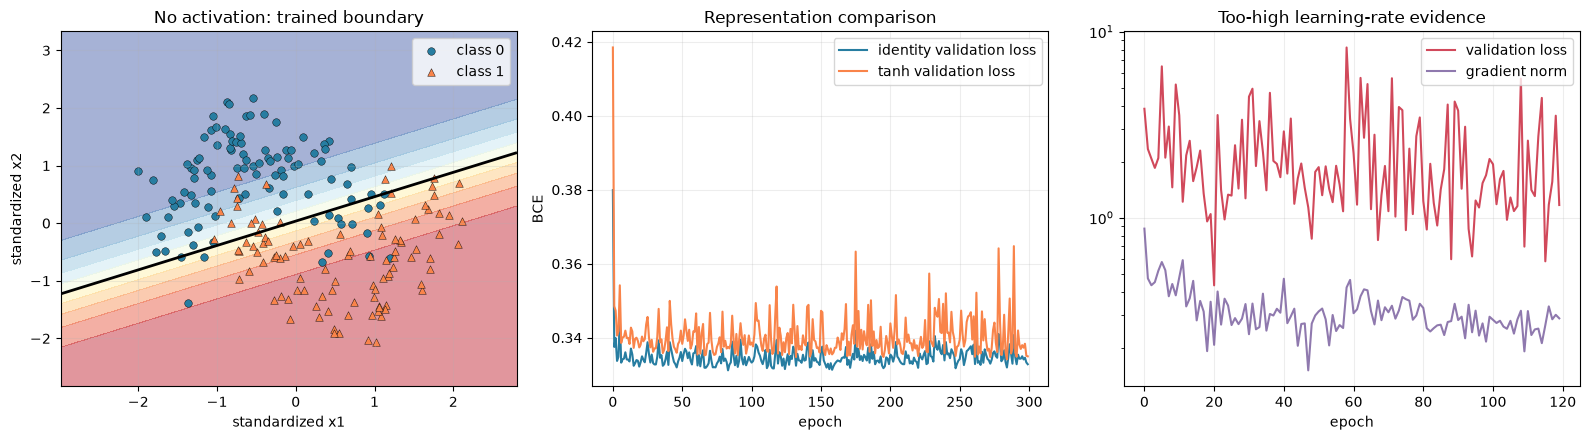

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
plot_boundary(axes[0], identity_parameters, 'identity', 'No activation: trained boundary')
axes[1].plot(identity_history['val_loss'], color='#277da1', label='identity validation loss')
axes[1].plot(baseline_history['val_loss'][:len(identity_history['val_loss'])], color='#f9844a', label='tanh validation loss')
axes[1].set(title='Representation comparison', xlabel='epoch', ylabel='BCE')
axes[1].legend()
if high_rate_history is None:
    axes[2].text(0.05, 0.6, high_rate_error, wrap=True)
    axes[2].set(title='High-rate bounded stop')
else:
    axes[2].plot(high_rate_history['val_loss'], color='#d1495b', label='validation loss')
    axes[2].plot(high_rate_history['gradient_norm'], color='#6a4c93', alpha=0.75, label='gradient norm')
    axes[2].set(title='Too-high learning-rate evidence', xlabel='epoch', yscale='log')
    axes[2].legend()
plt.tight_layout()
plt.show()

In [19]:
failure_diagnosis = {
    "identity_evidence_and_mechanism": "Validation accuracy is about 0.85 and the plotted 0.5 contour is linear. Without tanh, two affine layers collapse to one affine map and cannot form the moons boundary.",
    "high_rate_evidence_and_mechanism": "Validation loss spans a wide unstable range and exceeds 1.0. The large update scale overshoots useful descent even though the tanh model retains adequate capacity.",
    "targeted_recovery_for_each": "Restore tanh for the representation defect; lower only the learning rate for the optimization defect, preserving data, seeds, and architecture.",
}
assert all(value.strip() for value in failure_diagnosis.values())
print("Instructor failure diagnosis:", failure_diagnosis)

Instructor failure diagnosis: {'identity_evidence_and_mechanism': 'Validation accuracy is about 0.85 and the plotted 0.5 contour is linear. Without tanh, two affine layers collapse to one affine map and cannot form the moons boundary.', 'high_rate_evidence_and_mechanism': 'Validation loss spans a wide unstable range and exceeds 1.0. The large update scale overshoots useful descent even though the tanh model retains adequate capacity.', 'targeted_recovery_for_each': 'Restore tanh for the representation defect; lower only the learning rate for the optimization defect, preserving data, seeds, and architecture.'}


### Instructor Reveal: Failure Evidence

The reference identity run reaches validation accuracy near `0.850` with a linear contour. The high-rate
run remains finite in the current local environment but validation loss ranges roughly `0.43-8.22`;
a bounded non-finite stop is also acceptable evidence on another compatible runtime.

## Challenge: You Get One Isolated Experiment

Choose exactly one change: learning rate or hidden width. State a falsifiable hypothesis and the evidence expected in loss, accuracy, boundary, and gradient norm. Keep data, split, activation, batch size, epochs, and seeds fixed. Run once, then decide whether the evidence supports the hypothesis.

### Instructor Hint Ladder: One Change Only

Reject configurations that alter both rate and width. Require expected evidence in all four panels
before execution. A hypothesis may be rejected; the assessed skill is causal attribution from a
controlled run, not choosing a value that beats the baseline.

In [20]:
experiment_change = "learning_rate"
experiment_value = 0.3
experiment_hypothesis = "Halving eta will remain stable but learn more slowly, so the fixed 600-epoch budget will end on an earlier plateau than the baseline."
experiment_expected_evidence = {
    "loss": "Validation loss should decrease smoothly but remain above the baseline final loss.",
    "accuracy": "Validation accuracy may remain near the lower edge of the 0.85-0.95 band.",
    "boundary": "The boundary should be nonlinear but less developed around difficult moon regions.",
    "gradient_norm": "Norms should stay finite; update magnitude is smaller even if raw gradient norms are not uniformly smaller.",
}
assert experiment_change in {'learning_rate', 'hidden_dim'}
assert experiment_value is not None and float(experiment_value) > 0
assert not np.isclose(float(experiment_value), baseline_config[experiment_change])
assert experiment_hypothesis.strip() and all(value.strip() for value in experiment_expected_evidence.values())
experiment_config = baseline_config.copy()
experiment_config[experiment_change] = int(experiment_value) if experiment_change == 'hidden_dim' else float(experiment_value)
changed_keys = [key for key in baseline_config if experiment_config[key] != baseline_config[key]]
assert changed_keys == [experiment_change]

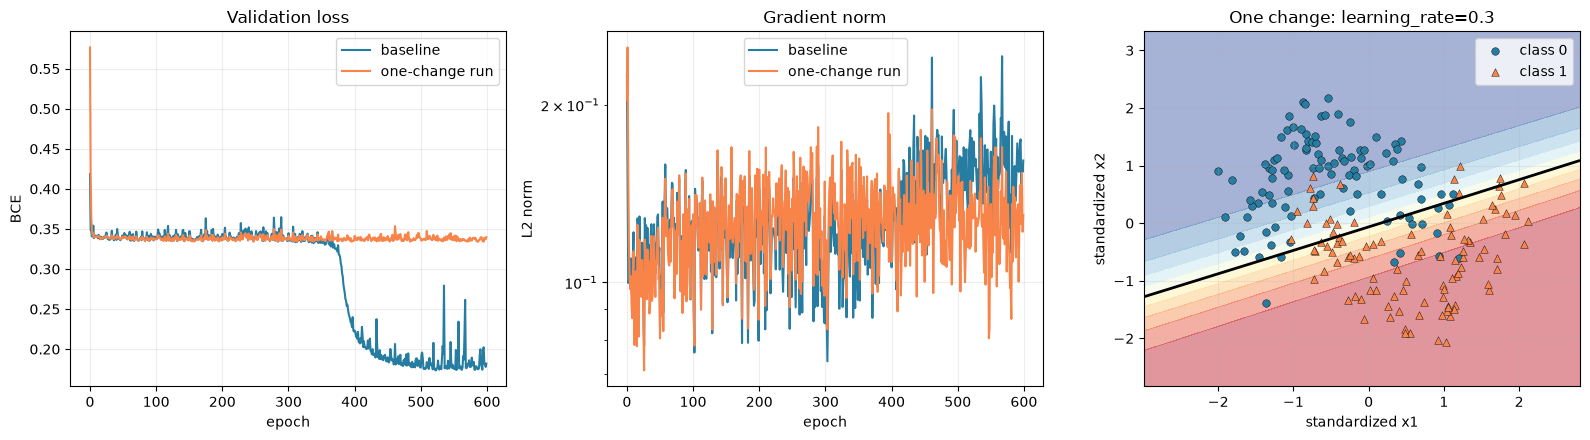

Baseline validation loss/accuracy: 0.1820 / 0.905
Experiment validation loss/accuracy: 0.3398 / 0.850
Instructor experiment interpretation: The evidence supports slower optimization: the 0.3 run remains finite and nonlinear but ends with higher validation loss and lower accuracy than the baseline under the same 600 epochs. Gradient norms remain bounded; eta, not the raw norm alone, reduced each update magnitude.


In [21]:
experiment_parameters, experiment_history = train_model(X_train, y_train, X_val, y_val, **experiment_config)
experiment_val_cache = forward(X_val, experiment_parameters, experiment_config['activation'])
experiment_val_loss = binary_cross_entropy(y_val, experiment_val_cache['P'])
experiment_val_accuracy = classification_accuracy(y_val, experiment_val_cache['P'])
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(baseline_history['val_loss'], label='baseline', color='#277da1')
axes[0].plot(experiment_history['val_loss'], label='one-change run', color='#f9844a')
axes[0].set(title='Validation loss', xlabel='epoch', ylabel='BCE')
axes[0].legend()
axes[1].plot(baseline_history['gradient_norm'], label='baseline', color='#277da1')
axes[1].plot(experiment_history['gradient_norm'], label='one-change run', color='#f9844a')
axes[1].set(title='Gradient norm', xlabel='epoch', ylabel='L2 norm', yscale='log')
axes[1].legend()
plot_boundary(axes[2], experiment_parameters, experiment_config['activation'], f"One change: {experiment_change}={experiment_config[experiment_change]}")
plt.tight_layout()
plt.show()
print(f"Baseline validation loss/accuracy: {baseline_val_loss:.4f} / {baseline_val_accuracy:.3f}")
print(f"Experiment validation loss/accuracy: {experiment_val_loss:.4f} / {experiment_val_accuracy:.3f}")
experiment_interpretation = (
    "The evidence supports slower optimization: the 0.3 run remains finite and nonlinear but ends "
    "with higher validation loss and lower accuracy than the baseline under the same 600 epochs. "
    "Gradient norms remain bounded; eta, not the raw norm alone, reduced each update magnitude."
)
assert experiment_interpretation.strip()
print("Instructor experiment interpretation:", experiment_interpretation)

## Optional Extension: Test the Other Variable

If the core challenge changed learning rate, optionally change hidden width; if it changed width, optionally change learning rate. Preserve every other baseline value and predict the evidence first. This extension is not required by the core checkpoint.

In [22]:
optional_change = "hidden_dim"
optional_value = 16
optional_prediction = "A width-16 tanh model should remain nonlinear and stable but may optimize more slowly than width 8 under the same seeded 600-epoch budget."
if optional_change is None or optional_value is None or not optional_prediction.strip():
    print("Optional second experiment skipped. Core checkpoint is unaffected.")
else:
    assert optional_change in {'learning_rate', 'hidden_dim'} and optional_change != experiment_change
    optional_config = baseline_config.copy()
    optional_config[optional_change] = int(optional_value) if optional_change == 'hidden_dim' else float(optional_value)
    assert [key for key in baseline_config if optional_config[key] != baseline_config[key]] == [optional_change]
    optional_parameters, optional_history = train_model(X_train, y_train, X_val, y_val, **optional_config)
    optional_val_cache = forward(X_val, optional_parameters, optional_config['activation'])
    optional_val_loss = binary_cross_entropy(y_val, optional_val_cache['P'])
    optional_val_accuracy = classification_accuracy(y_val, optional_val_cache['P'])
    print(f"Optional validation loss: {optional_val_loss:.4f}")
    print(f"Optional validation accuracy: {optional_val_accuracy:.3f}")
    optional_interpretation = (
        "The width-only run stays finite and nonlinear but ends near the lower accuracy band. This "
        "supports a fixed-budget optimization difference, not a universal claim that wider models fail."
    )
    assert optional_interpretation.strip()
    print("Instructor optional interpretation:", optional_interpretation)

Optional validation loss: 0.3420
Optional validation accuracy: 0.850
Instructor optional interpretation: The width-only run stays finite and nonlinear but ends near the lower accuracy band. This supports a fixed-budget optimization difference, not a universal claim that wider models fail.


## Reflect and Checkpoint

Cite one piece of evidence for optimization progress, one for representational adequacy, and one for plausible generalization. Explain why decreasing loss alone cannot validate every stage, and map each implemented function to one training-loop responsibility.

### Instructor Debrief and Delivery Notes

**Discussion triggers:** Which function owns each training-loop responsibility? Why can raw gradient
norms stay similar when a smaller eta makes smaller updates? Which panel separates capacity from
optimization most directly?

**Common failures:** Re-seeding the batch generator every epoch repeats one permutation; squeezing `P`
breaks the target contract; using validation statistics leaks information; mutating baseline parameters
contaminates variants; plotting a high-rate run on a linear axis hides instability. Restart and Run All
is the recovery for order/state drift.

**CPU/Colab note:** The path is generated-data, vectorized, and CPU-required. Last digits and timings may
differ in Colab, but shape invariants and broad bands should hold. Hosted Colab has not been executed.

**Acceptable alternatives:** Wider or narrower hidden experiments and other positive learning rates are
valid when exactly one field changes. A failed one-change hypothesis is acceptable if all four evidence
types are interpreted honestly.

In [23]:
reflection = {
    "optimization_evidence": "Training BCE falls from 0.686 to about 0.186 while gradient norms remain finite and the NaN guard catches corruption.",
    "representation_evidence": "The tanh model produces a curved boundary and outperforms the identity-hidden linear boundary.",
    "generalization_evidence": "Train/validation accuracy are close (about 0.915/0.905) and validation BCE tracks training BCE under the fixed split.",
    "loss_alone_limit": "Falling loss cannot verify split integrity, shape correctness, boundary family, finite gradients, or validation behavior; each needs separate evidence.",
    "function_to_loop_mapping": "initialize_parameters creates parameters; forward caches activations; binary_cross_entropy measures mismatch; backward computes sensitivities; mini_batches schedules examples; update_parameters changes copied arrays; train_model repeats, checks, and evaluates.",
}
assert all(value.strip() for value in reflection.values())
assert 0.65 <= initial_loss <= 0.75
assert baseline_train_loss < 0.35 and baseline_val_loss < 0.35
assert 0.85 <= baseline_train_accuracy <= 0.95
assert 0.85 <= baseline_val_accuracy <= 0.95
assert baseline_val_accuracy >= identity_val_accuracy
assert nan_guard_observed
high_rate_is_unstable = high_rate_history is None or max(high_rate_history['val_loss']) > 1.0
assert high_rate_is_unstable
assert changed_keys == [experiment_change]
print("LAB-D2-03 checkpoint passed: stages, baseline bands, boundary/gradient evidence, bounded diagnostics, and one-change experiment.")

LAB-D2-03 checkpoint passed: stages, baseline bands, boundary/gradient evidence, bounded diagnostics, and one-change experiment.


## Takeaways

- A complete training loop has separable responsibilities and testable invariants.
- Vectorization preserves the per-example function while adding a batch dimension.
- Stable loss and bounded finite-state checks turn silent corruption into actionable evidence.
- Loss, accuracy, boundary shape, and gradient norm test different hypotheses.
- One-variable experiments preserve attribution; a lower final scalar alone does not explain mechanism.

## Troubleshooting

| Symptom | Likely cause | Recovery |
|---|---|---|
| Initial loss is far from the broad `0.65-0.75` band | Initialization scale, seed, or split changed | Restart and restore supplied constants |
| `P` has shape `(B,)` | Output dimension was squeezed | Preserve `(B, 1)` through forward and targets |
| Gradient shapes mismatch parameters | A transpose or batch reduction is wrong | Compare each matrix product with the shape map |
| One epoch misses or repeats examples | Batch iterator reshuffles inside the slice loop | Create one permutation per epoch |
| Non-finite diagnostic appears | Rate is unstable or clipping/gradient logic is wrong | Inspect the reported epoch/batch and lower the isolated rate |
| Loss falls but boundary stays linear | Hidden activation is identity or absent | Inspect activation choice and boundary evidence |
| Validation differs from the sanity band | Seed, standardization, or experiment state leaked | Restart and run the baseline before variants |

## Continue

Return to the [LAB-D2-03 debrief](../student-guide/day-2-student-guide.md#lab-d2-03---train-a-neural-network-with-numpy). Review [LESSON-D2-04](../student-guide/day-2-student-guide.md#lesson-d2-04---vectorization-tensors-and-mini-batches), [LESSON-D2-05](../student-guide/day-2-student-guide.md#lesson-d2-05---train-a-network-from-scratch), [ACT-D2-03](../challenges/day-2-challenges.md#act-d2-03---batch-shape-map), [LAB-D2-01](LAB-D2-01-loss-learning-rate.ipynb), and [LAB-D2-02](LAB-D2-02-backprop-gradient-check.ipynb) as needed.